CUADERNO 1: carga y preparación de datos
Sistema de apoyo y triaje hospitalario

CUADERNO 1: CARGA Y PREPARACIÓN DE DATOS
Sistema de Apoyo al Triaje Hospitalario
📄 Cargando desde DATASET.csv...

INFORMACIÓN DEL DATASET
Dimensiones: (30, 16)

Columnas disponibles: ['ID', 'Nombre', 'Edad', 'Dolor (0-10)', 'Dificultad para respirar', 'Dolor en el pecho', 'Sangrado activo', 'Desmayo', 'Convulsiones', 'Embarazo', 'Enfermedades crónicas', 'Tiempo de evolución', 'Nivel de Prioridad (Salida)', 'Unnamed: 13', 'Tiempo de Evolución', '< 1 Hora']

PRIMERAS FILAS


,ID,Nombre,Edad,Dolor (0-10),Dificultad para respirar,Dolor en el pecho,Sangrado activo,Desmayo,Convulsiones,Embarazo,Enfermedades crónicas,Tiempo de evolución,Nivel de Prioridad (Salida),Unnamed: 13,Tiempo de Evolución,< 1 Hora
0,1,Ana López,24,3,No,No,No,No,No,Sí,No,< 1 hora,Nivel 4 - Menos urgente,NaN,NaN,1 - 6 Horas
1,2,Carlos Pérez,67,9,Sí,Sí,No,No,No,No aplica,Sí,< 1 hora,Nivel 2 - Emergencia,NaN,NaN,6 - 24 Horas
2,3,María Gómez,45,8,No,Sí,No,No,No,No,Sí,1–6 horas,Nivel 2 - Emergencia,NaN,NaN,> 24 Horas
3,4,José Ramírez,38,4,No,No,Sí,No,No,No aplica,No,< 1 hora,Nivel 3 - Urgente,NaN,NaN,NaN
4,5,Laura Torres,30,7,Sí,No,No,No,No,No,No,1–6 horas,Nivel 3 - Urgente,NaN,Embarazo,Sí



LIMPIEZA Y PREPROCESAMIENTO
✅ Columnas eliminadas: ['Unnamed: 13']

Columnas binarias a procesar: ['Dificultad para respirar', 'Dolor en el pecho', 'Sangrado activo', 'Desmayo', 'Convulsiones', 'Embarazo', 'Enfermedades crónicas']
✅ Dificultad para respirar: Mapeado a numérico
✅ Dolor en el pecho: Mapeado a numérico
✅ Sangrado activo: Mapeado a numérico
✅ Desmayo: Mapeado a numérico
✅ Convulsiones: Mapeado a numérico
✅ Embarazo: Mapeado a numérico
✅ Enfermedades crónicas: Mapeado a numérico
✅ Tiempo de evolución: Convertido a horas
✅ Nivel de Prioridad: Codificado numéricamente

VERIFICACIÓN DE VALORES NULOS
Tiempo de Evolución    29
< 1 Hora               24
dtype: int64
✅ Valores nulos imputados con 0

ANÁLISIS EXPLORATORIO DE DATOS

📊 Distribución de Niveles de Prioridad:
Nivel de Prioridad (Salida)
Nivel 1 - Resucitación      5
Nivel 2 - Emergencia       10
Nivel 3 - Urgente           7
Nivel 4 - Menos urgente     5
Nivel 5 - No urgente        3
Name: count, dtype: int64


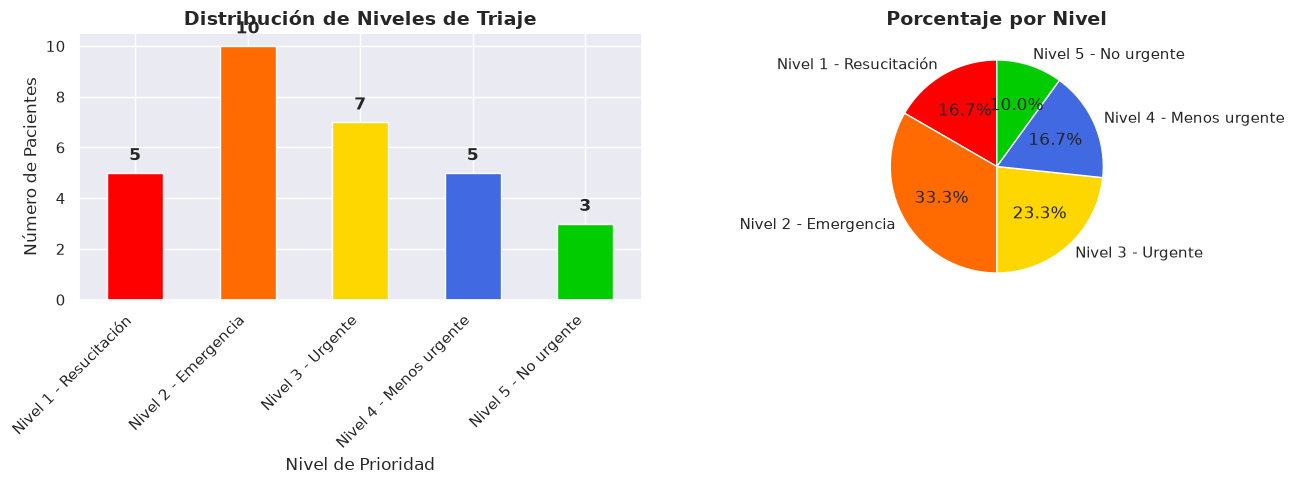


📊 Estadísticas Descriptivas:
           Edad  Dolor (0-10)  Dificultad para respirar  Dolor en el pecho  \
count  30.00000     30.000000                 30.000000          30.000000   
mean   44.20000      6.266667                  0.433333           0.366667   
std    18.03139      2.288402                  0.504007           0.490133   
min    19.00000      2.000000                  0.000000           0.000000   
25%    29.25000      5.000000                  0.000000           0.000000   
50%    39.50000      6.000000                  0.000000           0.000000   
75%    57.25000      8.000000                  1.000000           1.000000   
max    82.00000     10.000000                  1.000000           1.000000   

       Sangrado activo    Desmayo  Convulsiones   Embarazo  \
count        30.000000  30.000000     30.000000  30.000000   
mean          0.200000   0.166667      0.066667   0.166667   
std           0.406838   0.379049      0.253708   0.379049   
min           0.000

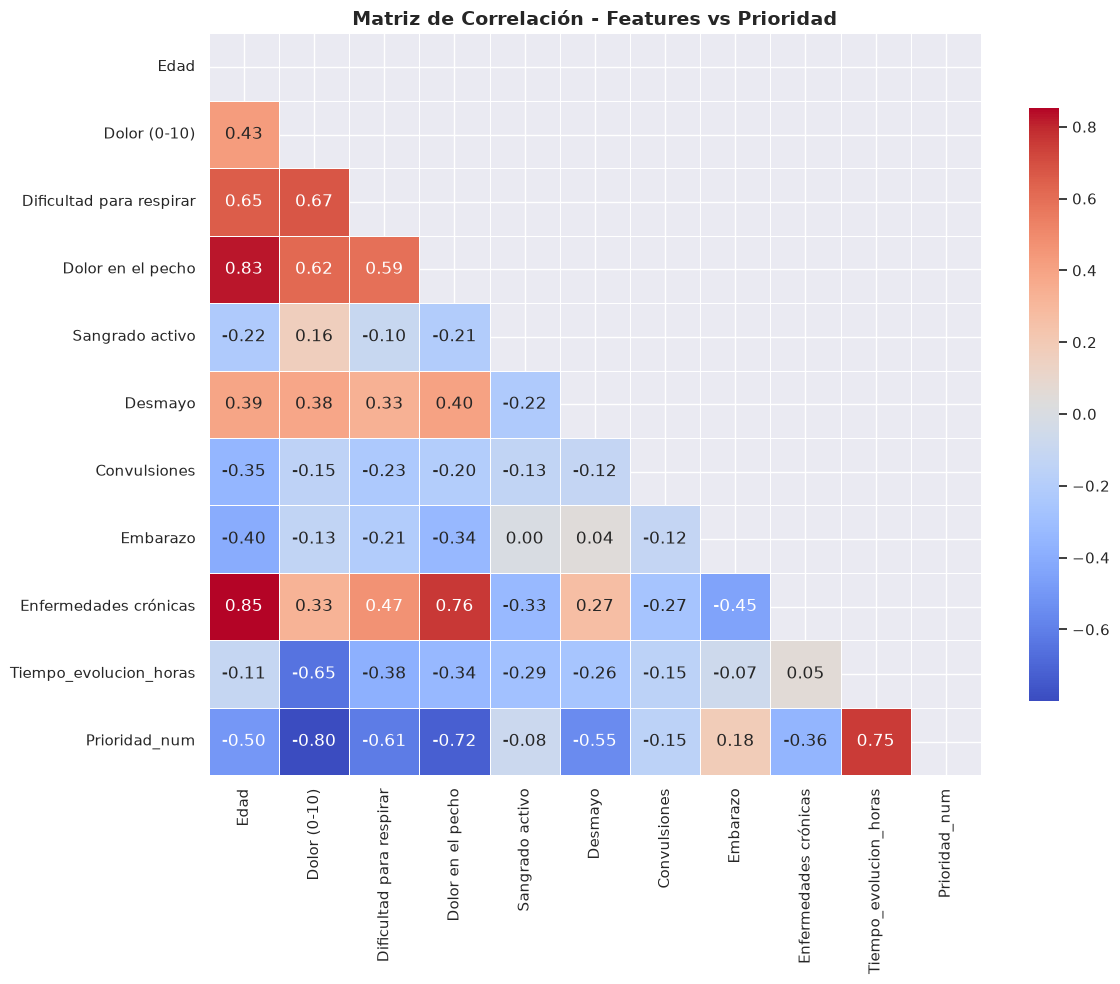


📊 Correlación con Nivel de Prioridad:
Prioridad_num               1.000000
Tiempo_evolucion_horas      0.753606
Embarazo                    0.184011
Sangrado activo            -0.082292
Convulsiones               -0.153955
Enfermedades crónicas      -0.356600
Edad                       -0.501629
Desmayo                    -0.552033
Dificultad para respirar   -0.614449
Dolor en el pecho          -0.722919
Dolor (0-10)               -0.799780
Name: Prioridad_num, dtype: float64

PREPARACIÓN PARA ENTRENAMIENTO
Features seleccionados: ['Edad', 'Dolor (0-10)', 'Dificultad para respirar', 'Dolor en el pecho', 'Sangrado activo', 'Desmayo', 'Convulsiones', 'Embarazo', 'Enfermedades crónicas', 'Tiempo_evolucion_horas']
Dimensiones X: (30, 10)
Dimensiones y: (30,)

Tamaño entrenamiento: 24
Tamaño prueba: 6

Distribución en entrenamiento:
Prioridad_num
1    4
2    8
3    6
4    4
5    2
Name: count, dtype: int64

Distribución en prueba:
Prioridad_num
1    1
2    2
3    1
4    1
5    1
Name: coun

In [3]:
# ============================================
# CUADERNO 1: CARGA Y PREPARACIÓN DE DATOS
# Sistema de Apoyo al Triaje Hospitalario
# ============================================

# 1. IMPORTAR LIBRERÍAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
import os
import joblib

# Crear directorios necesarios al inicio
os.makedirs('models', exist_ok=True)
os.makedirs('data', exist_ok=True)

warnings.filterwarnings('ignore')

# Configurar visualización
plt.style.use('default')
sns.set_theme()
sns.set_palette("husl")
%matplotlib inline

print("=" * 60)
print("CUADERNO 1: CARGA Y PREPARACIÓN DE DATOS")
print("Sistema de Apoyo al Triaje Hospitalario")
print("=" * 60)

# ============================================
# 2. CARGA DE DATOS
# ============================================

# Verificar si el archivo existe
if not os.path.exists('DATASET.csv'):
    print("⚠️ Archivo DATASET.csv no encontrado. Verifica la ubicación.")
    if os.path.exists('DATASET.xlsx'):
        print("📄 Cargando desde DATASET.xlsx...")
        df = pd.read_excel('DATASET.xlsx', sheet_name='Hoja1')
    else:
        raise FileNotFoundError("No se encontró DATASET.csv ni DATASET.xlsx")
else:
    print("📄 Cargando desde DATASET.csv...")
    df = pd.read_csv('DATASET.csv', sep=';', encoding='utf-8-sig')

# Mostrar información básica
print("\n" + "=" * 60)
print("INFORMACIÓN DEL DATASET")
print("=" * 60)
print(f"Dimensiones: {df.shape}")
print(f"\nColumnas disponibles: {df.columns.tolist()}")

# Mostrar primeras filas
print("\n" + "=" * 60)
print("PRIMERAS FILAS")
print("=" * 60)
display(df.head())

# ============================================
# 3. LIMPIEZA Y PREPROCESAMIENTO
# ============================================

print("\n" + "=" * 60)
print("LIMPIEZA Y PREPROCESAMIENTO")
print("=" * 60)

# 3.1 Eliminar columnas vacías o redundantes
columnas_vacias = [col for col in df.columns if col.startswith('Unnamed') or col == '' or col is None]
if columnas_vacias:
    df = df.drop(columns=columnas_vacias, errors='ignore')
    print(f"✅ Columnas eliminadas: {columnas_vacias}")

# 3.2 Mapear valores categóricos a numéricos
mapa_si_no = {'Sí': 1, 'No': 0, 'No aplica': 0, 'Si': 1, 'si': 1, 'no': 0}

columnas_binarias = [
    'Dificultad para respirar',
    'Dolor en el pecho',
    'Sangrado activo',
    'Desmayo',
    'Convulsiones',
    'Embarazo',
    'Enfermedades crónicas'
]

# Filtrar columnas que existen
columnas_binarias = [col for col in columnas_binarias if col in df.columns]
print(f"\nColumnas binarias a procesar: {columnas_binarias}")

for col in columnas_binarias:
    df[col] = df[col].map(mapa_si_no).fillna(0)
    print(f"✅ {col}: Mapeado a numérico")

# 3.3 Mapear Tiempo de evolución a valores numéricos (horas)
mapa_tiempo = {
    '< 1 hora': 0.5,
    '1–6 horas': 3.5,
    '6–24 horas': 15,
    '> 24 horas': 30,
    '< 1 hora': 0.5
}

if 'Tiempo de evolución' in df.columns:
    df['Tiempo_evolucion_horas'] = df['Tiempo de evolución'].map(mapa_tiempo)
    print("✅ Tiempo de evolución: Convertido a horas")

# 3.4 Codificar variable objetivo (Nivel de Prioridad)
mapa_prioridad = {
    'Nivel 1 - Resucitación': 1,
    'Nivel 2 - Emergencia': 2,
    'Nivel 3 - Urgente': 3,
    'Nivel 4 - Menos urgente': 4,
    'Nivel 5 - No urgente': 5
}

if 'Nivel de Prioridad (Salida)' in df.columns:
    df['Prioridad_num'] = df['Nivel de Prioridad (Salida)'].map(mapa_prioridad)
    print("✅ Nivel de Prioridad: Codificado numéricamente")

# 3.5 Verificar y manejar valores nulos
print("\n" + "=" * 60)
print("VERIFICACIÓN DE VALORES NULOS")
print("=" * 60)
nulos = df.isnull().sum()
if any(nulos > 0):
    print(nulos[nulos > 0])
    # Imputar valores nulos si es necesario (por simplicidad, llenar con 0 o media)
    df = df.fillna(0)
    print("✅ Valores nulos imputados con 0")
else:
    print("✅ No hay valores nulos en el dataset")

# ============================================
# 4. ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# ============================================

print("\n" + "=" * 60)
print("ANÁLISIS EXPLORATORIO DE DATOS")
print("=" * 60)

# 4.1 Distribución de la variable objetivo
print("\n📊 Distribución de Niveles de Prioridad:")
distribucion = df['Nivel de Prioridad (Salida)'].value_counts().sort_index()
print(distribucion)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colores = ['#FF0000', '#FF6B00', '#FFD700', '#4169E1', '#00CC00']
ax1 = axes[0]
distribucion.plot(kind='bar', ax=ax1, color=colores)
ax1.set_title('Distribución de Niveles de Triaje', fontsize=14, fontweight='bold')
ax1.set_xlabel('Nivel de Prioridad')
ax1.set_ylabel('Número de Pacientes')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
for i, v in enumerate(distribucion.values):
    ax1.text(i, v + 0.5, str(v), ha='center', fontweight='bold')

ax2 = axes[1]
distribucion.plot(kind='pie', ax=ax2, autopct='%1.1f%%', colors=colores, startangle=90)
ax2.set_title('Porcentaje por Nivel', fontsize=14, fontweight='bold')
ax2.set_ylabel('')

plt.tight_layout()
plt.savefig('distribucion_prioridad.png', dpi=300, bbox_inches='tight')
plt.show()

# 4.2 Estadísticas descriptivas
print("\n📊 Estadísticas Descriptivas:")
columnas_numericas = ['Edad', 'Dolor (0-10)'] + columnas_binarias + ['Tiempo_evolucion_horas', 'Prioridad_num']
columnas_existentes = [col for col in columnas_numericas if col in df.columns]
print(df[columnas_existentes].describe())

# 4.3 Matriz de correlación
plt.figure(figsize=(12, 10))
corr_matrix = df[columnas_existentes].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Matriz de Correlación - Features vs Prioridad', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('matriz_correlacion.png', dpi=300, bbox_inches='tight')
plt.show()

# 4.4 Correlación con la variable objetivo
corr_con_prioridad = corr_matrix['Prioridad_num'].sort_values(ascending=False)
print("\n📊 Correlación con Nivel de Prioridad:")
print(corr_con_prioridad)

# ============================================
# 5. PREPARACIÓN PARA ENTRENAMIENTO
# ============================================

print("\n" + "=" * 60)
print("PREPARACIÓN PARA ENTRENAMIENTO")
print("=" * 60)

# 5.1 Selección de features y target
features = ['Edad', 'Dolor (0-10)'] + columnas_binarias + ['Tiempo_evolucion_horas']
X = df[features]
y = df['Prioridad_num']

print(f"Features seleccionados: {features}")
print(f"Dimensiones X: {X.shape}")
print(f"Dimensiones y: {y.shape}")

# 5.2 División en entrenamiento y prueba (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTamaño entrenamiento: {len(X_train)}")
print(f"Tamaño prueba: {len(X_test)}")
print("\nDistribución en entrenamiento:")
print(y_train.value_counts().sort_index())
print("\nDistribución en prueba:")
print(y_test.value_counts().sort_index())

# 5.3 Escalamiento de features numéricos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=features)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=features)

# 5.4 Guardar datos procesados
print("\n" + "=" * 60)
print("GUARDANDO DATOS PROCESADOS")
print("=" * 60)

# Guardar scaler y otros objetos
joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(features, 'models/features_list.pkl')
joblib.dump(mapa_prioridad, 'models/mapa_prioridad.pkl')

# Guardar conjuntos de datos
X_train_scaled_df.to_csv('data/X_train_scaled.csv', index=False)
X_test_scaled_df.to_csv('data/X_test_scaled.csv', index=False)
pd.DataFrame(y_train).to_csv('data/y_train.csv', index=False)
pd.DataFrame(y_test).to_csv('data/y_test.csv', index=False)

print("✅ Archivos guardados:")
print("   - models/scaler.pkl")
print("   - models/features_list.pkl")
print("   - models/mapa_prioridad.pkl")
print("   - data/X_train_scaled.csv")
print("   - data/X_test_scaled.csv")
print("   - data/y_train.csv")
print("   - data/y_test.csv")

# ============================================
# 6. RESUMEN FINAL
# ============================================

print("\n" + "=" * 60)
print("RESUMEN FINAL - CUADERNO 1")
print("=" * 60)
print(f"Total de registros: {len(df)}")
print(f"Features: {len(features)}")
print(f"Tamaño entrenamiento: {len(X_train)}")
print(f"Tamaño prueba: {len(X_test)}")
print(f"Clases: {sorted(y.unique())}")
print("\nDistribución completa:")
print(df['Nivel de Prioridad (Salida)'].value_counts().sort_index())
print("\n✅ Cuaderno 1 completado exitosamente.")